# Projeto: Análise de Churn

## Objetivo
Desenvolver um modelo preditivo para identificar clientes com alta probabilidade de cancelar serviços em uma empresa de telecomunicações, permitindo intervenções proativas para retenção.

## Sobre o Dataset
Dataset da IBM com informações de clientes de telecomunicações. Cada linha representa um cliente com atributos demográficos, de serviços contratados e informações da conta.

## Principais Variáveis:
**Demográficas:** gender, SeniorCitizen, Partner, Dependents

**Serviços:** PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, TechSupport, StreamingTV, StreamingMovies

**Conta:** tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

**Target:** Churn (Yes/No) - indica se o cliente cancelou

## Problemas de Qualidade:
- TotalCharges contém valores vazios como string
- Desbalanceamento de classes (73% No, 27% Yes)
- Tipos de dados inconsistentes

## Metodologia Proposta:
- Análise exploratória das relações entre variáveis
- Tratamento de dados faltantes e transformação de tipos
- Feature engineering e seleção de variáveis
- Modelagem com algoritmos de classificação
- Avaliação por métricas de negócio (recall, F1-score)

# Step #1 - Importing dependecies

In [92]:
# Base Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pickle

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Step #2 - Load the Data

In [7]:
# Load the data
df = pd.read_csv('../../Datasets/customer-churn/customer-churn.csv')
# Analyze the Shape
print(
    f"The shape of the dataset is {df.shape}.\nIt has {df.shape[0]} rows and {df.shape[1]} columns.")
# Analyze the first 5 columns
df.head()

The shape of the dataset is (7043, 21).
It has 7043 rows and 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**We can see that we are not able to access all 21 columns because the width is limited; therefore, we need to set the parameter "display.max_columns"**

In [8]:
pd.set_option("display.max_columns", None)

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step #3 - Check the Data

In [12]:
# Information of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
# Printing the Unique Values in all the columns
for col in df_new.columns:
    print(f"Column: {col}\nValues: {df_new[col].unique()}")
    print(df_new[col].dtype)
    print("-" * 50)

Column: gender
Values: ['Female' 'Male']
object
--------------------------------------------------
Column: SeniorCitizen
Values: [0 1]
int64
--------------------------------------------------
Column: Partner
Values: ['Yes' 'No']
object
--------------------------------------------------
Column: Dependents
Values: ['No' 'Yes']
object
--------------------------------------------------
Column: tenure
Values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
int64
--------------------------------------------------
Column: PhoneService
Values: ['No' 'Yes']
object
--------------------------------------------------
Column: MultipleLines
Values: ['No phone service' 'No' 'Yes']
object
--------------------------------------------------
Column: InternetService
Values: ['DSL' 'Fiber optic' 'No']
object
-------------------------

In [24]:
# Verify if there's any null value
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [33]:
# Checking the class distribution of target column
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Notes::**
1. CustomerID is not required for the model
2. No null values in the DataFrame
3. Class imbalance identified in the **target**

## Step #3.1 - Preparing the Data

In [ ]:
# CustomerID column is not required for modelling
df_new = df.drop(columns=['customerID'])

In [14]:
df_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# TotalCharges is numeric but the type rn is Object, let's change that
df['TotalCharges'] = df['TotalCharges'].astype(float)

ValueError: could not convert string to float: ' '

**We noticed that the TotalCharges field has empty values, which prevents us from converting it to a float. Let's fix this.**

In [28]:
# Identify the empty values
df[df['TotalCharges'] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
# Quantity of the empty values
len(df[df['TotalCharges'] == " "])

11

In [30]:
# Replace the empty values
df_new['TotalCharges'] = df_new['TotalCharges'].replace({" ": "0.0"})

In [31]:
# Fix the type of the TotalCharges
df_new['TotalCharges'] = df_new['TotalCharges'].astype(float)

In [ ]:
# Check if is fixed
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Step #4 - Exploratory Data Analysis (EDA)

In [ ]:
# Statistics
df_new.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


**Numerical Features**

In [73]:
# Histogram Function

def plot_histogram(df, column_name):
    plt.figure(figsize=(5, 3))

    sns.histplot(
        df[column_name],
        kde=True,
        color=cm.Blues(0.6)
    )

    mean = df[column_name].mean()
    median = df[column_name].median()

    plt.axvline(mean, color=cm.Blues(0.8), linestyle='--', label='Mean')
    plt.axvline(median, color=cm.Blues(0.4), label='Median')

    plt.title(f"Distribution of {column_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

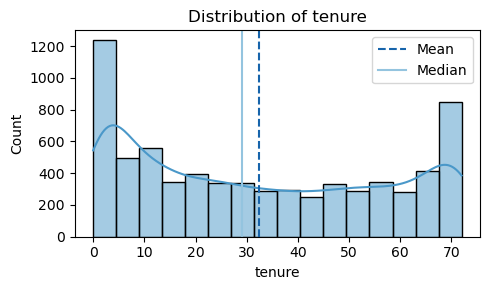

In [74]:
# Distribution of tenure
plot_histogram(df_new, "tenure")

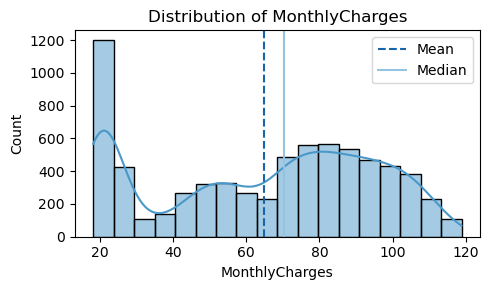

In [75]:
# Distribution of MonthlyCharges
plot_histogram(df_new, "MonthlyCharges")

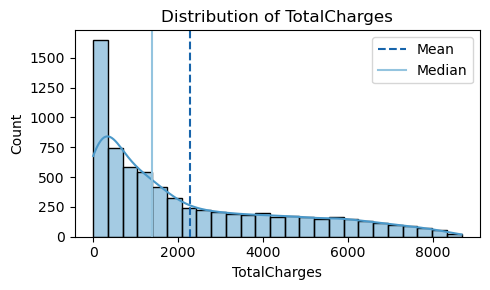

In [76]:
# Distribution of TotalCharges
plot_histogram(df_new, "TotalCharges")

In [ ]:
# Boxplot Function

def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    
    blue_color = cm.Blues(0.6)

    sns.boxplot(
        y=df[column_name],
        color=blue_color
    )

    plt.title(f"Box Plot of {column_name}")
    plt.ylabel(column_name)
    plt.tight_layout()
    plt.show()

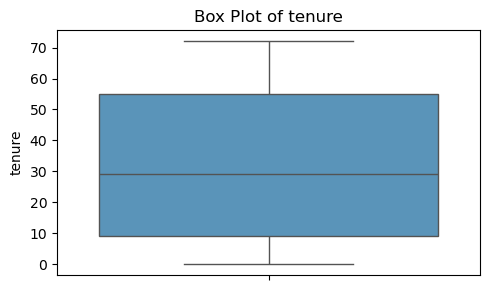

In [65]:
# Boxplot of tenure
plot_boxplot(df_new, "tenure")

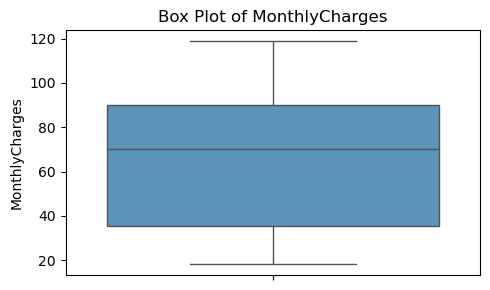

In [66]:
# Boxplot of MonthlyCharges
plot_boxplot(df_new, "MonthlyCharges")

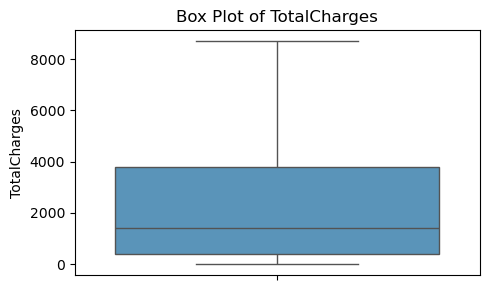

In [67]:
# Boxplot of TotalCharges
plot_boxplot(df_new, "TotalCharges")

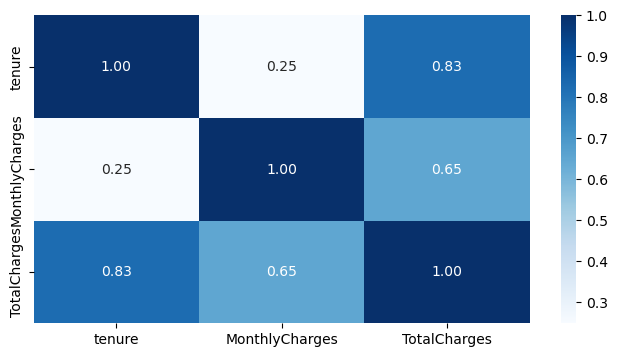

In [54]:
# Correlation for heatmap

plt.figure(figsize=(8, 4))
sns.heatmap(df_new[['tenure', 'MonthlyCharges', 'TotalCharges']
                   ].corr(), annot=True, cmap='Blues', fmt='.2f',)
plt.show()

**Categorical Features**

In [77]:
# First, let's get our categorical columns

object_cols = df_new.select_dtypes(include='object').columns.to_list()

object_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [ ]:
# See that we're missing the column SeniorCitizen, let's add it

object_cols = ['SeniorCitizen'] + object_cols
object_cols

['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [ ]:
# Plot Categorial Features Function
def plot_categorical_features(df, cols):
    n_cols = 3
    n_rows = (len(cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        sns.countplot(
            x=df[col],
            ax=ax,
            color=cm.Blues(0.6)
        )
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

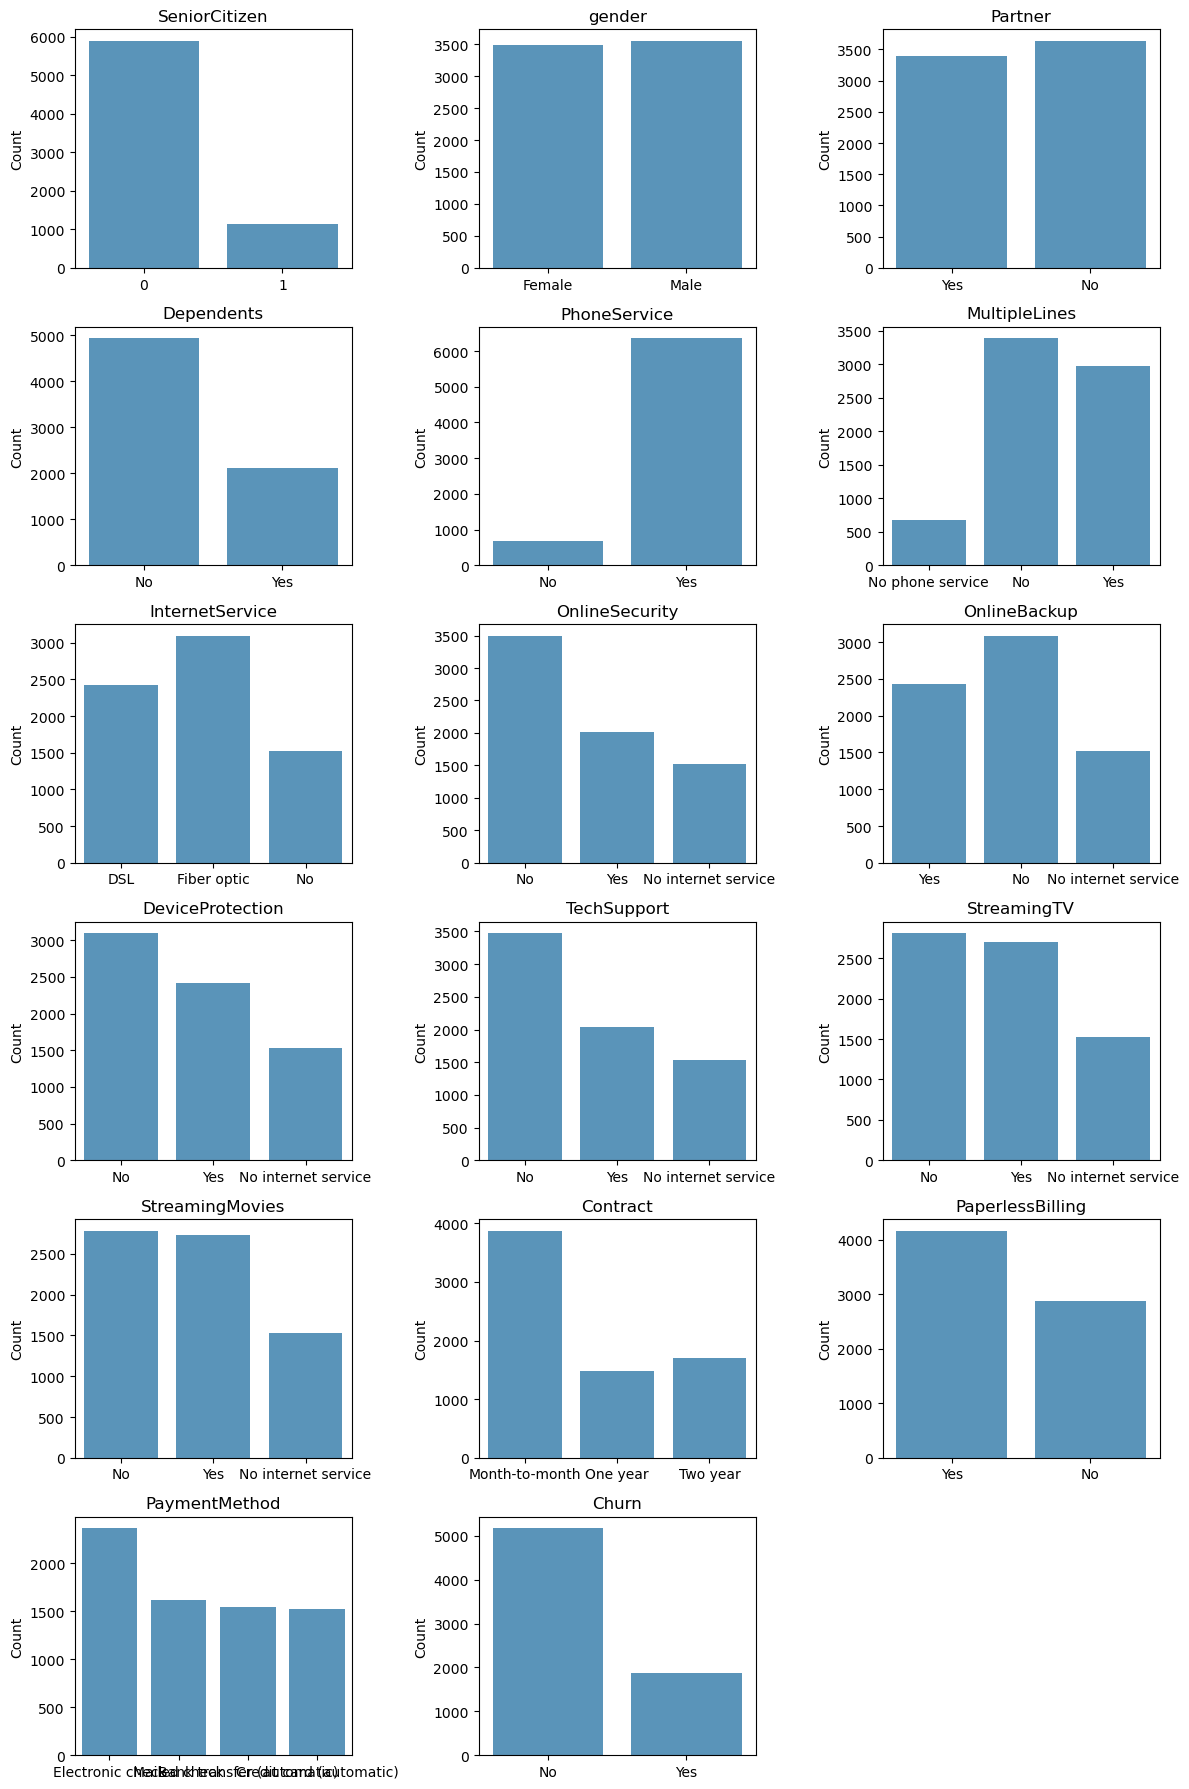

In [ ]:
# Count of Categorical Features
plot_categorical_features(df_new, object_cols)

# Step #5 - Data Preprocessing

**Label Encoding of target column**

In [84]:
df_new['Churn'] = df_new['Churn'].replace({'Yes': 1, 'No': 0})
df_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [85]:
print(df_new['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**Label Encoding of categorial features**

In [88]:
# Identify the columns with object data type
new_object_cols = df_new.select_dtypes(include=object).columns

In [89]:
new_object_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [ ]:
# Dictionary to store one LabelEncoder per categorical column
# This allows us to reuse the same encoders later (e.g. during inference)
encoders = {}

# Loop through each categorical column that needs encoding
for column in new_object_cols:
    
    # Create a new LabelEncoder instance for the current column
    label_encoder = LabelEncoder()
    
    # Fit the encoder on the column values and transform them into numeric labels
    # Example: ['Yes', 'No'] -> [1, 0]
    df_new[column] = label_encoder.fit_transform(df_new[column])
    
    # Store the fitted encoder in the dictionary using the column name as the key
    encoders[column] = label_encoder

# Save the dictionary of fitted encoders to a file
# This ensures we can apply the same encoding to new/unseen data later
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)


In [96]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [ ]:
# Let's analyze our DataFrame encoded
df_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


**Standardization**

In [105]:
# TotalCharges is very assimetric, only standardizes might not be ideal, so we have to Log + Standardization. Let's create a new column
df_new['TotalCharges_log'] = np.log1p(df_new['TotalCharges'])

# Apply the Scaler
scaler = StandardScaler()
cols = ['tenure', 'MonthlyCharges', 'TotalCharges_log']
df_new[cols] = scaler.fit_transform(df_new[cols])

# Drop the original column
df_new = df_new.drop(columns=['TotalCharges'])

df_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges_log
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,0,-2.232521
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,0,0.390027
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,1,-1.427310
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,0,0.373379
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,1,-1.213563


**Train and Test Data Split**

In [112]:
# Set the X and y
X = df_new.drop(columns='Churn')
y = df_new['Churn']

In [113]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

**We have a problem here, the Target is imbalanced, as we see below. To fix it, we call the SMOTE**

In [121]:
y_train.value_counts()

Churn
0    3635
1    1295
Name: count, dtype: int64

**Synthetic Minority Oversampling Technique (SMOTE)**

In [ ]:
# Initialyze the smote
smote = SMOTE()

In [ ]:
# Set the data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
# Check the balance of the target y
print(y_train_smote.value_counts())

Churn
0    3635
1    3635
Name: count, dtype: int64


# Step #6 - Model Training

In [122]:
# Dict of models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier()
}

In [124]:
# Dict to store the cross validation scores
cv_scores = {}

# 10-fold cross validation for each model
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, X_train_smote,
                             y_train_smote, cv=10, scoring='accuracy')
    cv_scores[model_name] = scores
    print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
    print("-" * 70)

Training Logistic Regression with default parameters
Logistic Regression cross-validation accuracy: 0.78
----------------------------------------------------------------------
Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
----------------------------------------------------------------------


In [127]:
selected_model = models['Decision Tree']
selected_model.fit(X_train_smote, y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Step #7 - Model Evaluation

In [128]:
# Evaluate on test data
y_test_pred = selected_model.predict(X_test)

print(f"Accuracy score:\n {accuracy_score(y_test, y_test_pred)}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_test_pred)}")
print(f"Classification Report:\n {classification_report(y_test, y_test_pred)}")

Accuracy score:
 0.7160435399905348
Confusion Matrix:
 [[1180  359]
 [ 241  333]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.77      0.80      1539
           1       0.48      0.58      0.53       574

    accuracy                           0.72      2113
   macro avg       0.66      0.67      0.66      2113
weighted avg       0.74      0.72      0.72      2113



# Step #8 - Save the trained model as a pickle file

In [131]:
# Save the model
model_data = {"model": selected_model, "feature_names": X.columns.to_list()}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

# Step #9 - Load the saved model and build a Predictive System

In [137]:
# Load the saved model and the encoders

with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data['model']
feature_names = model_data['feature_names']

In [143]:
# Random Data
data_dict_encoded = {
    "gender": 1,             # Female
    "SeniorCitizen": 0,
    "Partner": 1,            # Yes
    "Dependents": 0,         # No
    "tenure": 1,
    "PhoneService": 0,       # No
    "MultipleLines": 2,      # No phone service
    "InternetService": 0,    # DSL
    "OnlineSecurity": 0,     # No
    "OnlineBackup": 1,       # Yes
    "DeviceProtection": 0,   # No
    "TechSupport": 0,        # No
    "StreamingTV": 0,        # No
    "StreamingMovies": 0,    # No
    "Contract": 0,           # Month-to-month
    "PaperlessBilling": 1,   # Yes
    "PaymentMethod": 0,      # Electronic check
    "MonthlyCharges": 29.85,
    "TotalCharges_log": 29.85
}

# Transform dictionary into a DataFrame
data_dict_df = pd.DataFrame([data_dict_encoded])

# Make a Prediction
prediction = loaded_model.predict(data_dict_df)
pred_prob = loaded_model.predict_proba(data_dict_df)

# Results
print(prediction)
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'} ")
print(f"Prediction Probability: {pred_prob}")

[0]
Prediction: No Churn 
Prediction Probability: [[1. 0.]]
